In [1]:
import scarf
import scarf.plotting as splt

scarf.fetch_dataset("tenx_5K_pbmc_rnaseq", save_path="scarf_datasets")
reader = scarf.CrH5Reader("scarf_datasets/tenx_5K_pbmc_rnaseq/data.h5")
scarf.CrToZarr(reader, zarr_loc="scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr").dump(
    batch_size=1000
)

Writing countsT shape=(33538, 5025) chunks=(33538, 5025)



In [2]:
ds = scarf.DataStore(
    "scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr", nthreads=4, min_features_per_cell=10
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures"], highs=[15000, 4000], lows=[1000, 500]
)

Minimum cell count (502) is lower than size factor multiplier (1000)



597 cells flagged for filtering out using attribute RNA_nCounts



461 cells flagged for filtering out using attribute RNA_nFeatures



Calculating summary statistics



(RNA) feature stats block 1/1: read 1.0s (r2) compute 0.3s rss 927 MiB



Calculating HVGs



500 genes marked as HVGs



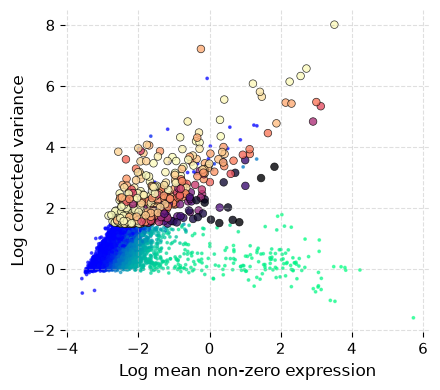

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 1.2s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.1s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

ANN recall: 99.95%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 19.1s (7/7 steps, 19.0s in logged steps)



Training UMAP:   0%|                                                                                          …

In [3]:
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key="hvgs", k=11, dims=15, n_centroids=100)
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)
ds.run_leiden_clustering(resolution=0.5)

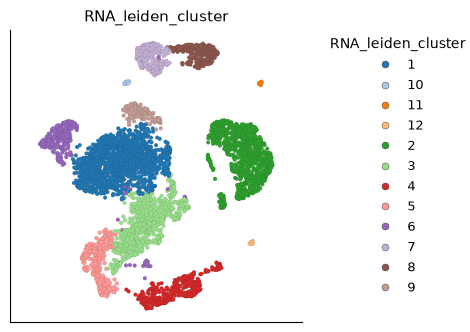

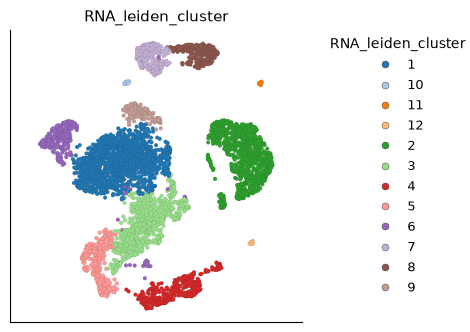

In [4]:
result = splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_leiden_cluster",
    show=False,
)
result.figure